In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
df = pd.read_stata("D://1 Univesrity work//Lect 2//Data Science Lab//Determinants-of-Financial-Literacy-Among-Italian-Adults-Evidence-from-the-IACOFI-2023-Survey//Dataset//Database_ENG.dta")

In [3]:
print(df.shape)

(4862, 219)


In [4]:
df.head()

,qd1,qd7,qd7_a,qd2,qd3,qd5_1,qd5_2,qd5_3,qd5_4,qd5_5,...,qd6_2,qd6_3,qd6_4,qd6_5,qd6_6,qd6_7,qd9,qd12,qd13,wght
0,1,68,NaN,1,3,1,0,0,0,0,...,2,1,4,3,1,2,5,1,2,0.401783
1,1,36,NaN,4,2,0,0,1,0,0,...,1,2,2,3,2,1,5,1,-99,0.639130
2,0,64,NaN,4,3,0,1,0,0,0,...,3,3,3,2,2,2,5,1,-99,0.852871
3,0,50,NaN,4,4,0,0,0,0,1,...,2,2,2,2,2,2,1,1,-99,0.951568
4,1,66,NaN,4,3,0,1,0,0,0,...,3,1,4,4,2,2,7,1,1,0.945395


In [5]:
df.columns.tolist()

['qd1',
 'qd7',
 'qd7_a',
 'qd2',
 'qd3',
 'qd5_1',
 'qd5_2',
 'qd5_3',
 'qd5_4',
 'qd5_5',
 'qd5_6',
 'qd5_7',
 'qd5_99',
 'qd5_ad',
 'qd5_ch',
 'qd10',
 'qd14',
 'qf1_a',
 'qf1',
 'qf2_1',
 'qf2_2',
 'qf2_3',
 'qf2_4',
 'qf2_5',
 'qf2_6',
 'qf3_1',
 'qf3_2',
 'qf3_3',
 'qf3_5',
 'qf3_6',
 'qf3_7',
 'qf3_8',
 'qf3_81',
 'qf3_98',
 'qf4',
 'qf8',
 'qf9_1',
 'qf9_2',
 'qf9_3',
 'qf9_4',
 'qf9_5',
 'qf9_6',
 'qf9_7',
 'qf9_8',
 'qf9_9',
 'qf9_10',
 'qf9_11',
 'qf9_12',
 'qf11',
 'qf12_1_1',
 'qf12_1_2',
 'qf12_1_3',
 'qf12_2_1',
 'qf12_2_2',
 'qf12_3_1',
 'qf12_3_2',
 'qf12_3_3',
 'qf12_3_7',
 'qf12_4_1',
 'qf12_4_2',
 'qf12_5_1',
 'qf12_5_3',
 'qf12_6_1',
 'qf12_6_2',
 'qf12_7_1',
 'qf12_97',
 'qf12_99',
 'qf13',
 'qp1_8',
 'qp1_9',
 'qp1_13',
 'qp1_12',
 'qp1_2',
 'qp1_1',
 'qp1_11',
 'qp1_16',
 'qp1_add_2',
 'qp1_3',
 'qp1_5',
 'qp1_add_1',
 'qp1_7',
 'qp1_14',
 'qp1_15',
 'qp1_17',
 'qp1_add_3',
 'qp1_add_4',
 'qp1_add_5',
 'qp1_98',
 'qp2_8',
 'qp2_9',
 'qp2_13',
 'qp2_12',
 'qp2_2'

In [8]:
invalid_values = [-99, -98, -97, -999]
df.replace(invalid_values, np.nan, inplace=True)

In [9]:
missing = df.isna().sum()

missing[missing > 0].sort_values(ascending=False)

qd7_a       4643
qp3_17      4599
qp2_17      4597
qf12_2_1    4373
qf12_3_7    4366
            ... 
qf2_1         23
qd5_99        21
qd10          20
qd14          20
qd12          12
Length: 186, dtype: int64

In [17]:
selected_columns = [
    'qd1','qd7','qd2','qd3','qd9','qd10','qd13','qd14',
    'qk3','qk4','qk5','qk6','qk10'
]


In [18]:
data = df[selected_columns].copy()
data.head()

,qd1,qd7,qd2,qd3,qd9,qd10,qd13,qd14,qk3,qk4,qk5,qk6,qk10
0,1,68.0,1,3,5,6.0,2.0,1.0,3.0,0.0,102.0,1.0,1.0
1,1,36.0,4,2,5,2.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN
2,0,64.0,4,3,5,4.0,NaN,1.0,4.0,0.0,120.0,4.0,0.0
3,0,50.0,4,4,1,1.0,NaN,1.0,4.0,0.0,20.0,3.0,1.0
4,1,66.0,4,3,7,6.0,1.0,1.0,3.0,0.0,NaN,NaN,1.0


In [19]:
data['qk3_correct'] = (data['qk3'] == 3).astype(int)
data['qk4_correct'] = (data['qk4'] == 0).astype(int)
data['qk5_correct'] = (data['qk5'] == 102).astype(int)
data['qk6_correct'] = (data['qk6'] == 1).astype(int)
data['qk10_correct'] = (data['qk10'] == 1).astype(int)

data['financial_knowledge_score'] = (
    data['qk3_correct'] +
    data['qk4_correct'] +
    data['qk5_correct'] +
    data['qk6_correct'] +
    data['qk10_correct']
)

In [20]:
data['financial_knowledge_score'].describe()

count    4862.000000
mean        2.878239
std         1.410275
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: financial_knowledge_score, dtype: float64

In [21]:
# 1. rename again (safe)
data = data.rename(columns={
    'qd9': 'education',
    'qd7': 'age',
    'qd1': 'gender',
    'qd2': 'region',
    'qd3': 'urban',
    'qd10': 'employment',
    'qd13': 'income',
    'qd14': 'internet_access'
})

# 2. check
print(data.columns)

# 3. groupby
data.groupby('education')['financial_knowledge_score'].mean()

Index(['gender', 'age', 'region', 'urban', 'education', 'employment', 'income',
       'internet_access', 'qk3', 'qk4', 'qk5', 'qk6', 'qk10', 'qk3_correct',
       'qk4_correct', 'qk5_correct', 'qk6_correct', 'qk10_correct',
       'financial_knowledge_score'],
      dtype='object')


education
1     3.014493
2     3.309417
3     3.098253
4     3.186275
5     2.990533
6     2.510903
7     2.270609
8     1.614035
9     1.824176
10    0.190476
Name: financial_knowledge_score, dtype: float64

In [22]:
print(data.columns.tolist())

['gender', 'age', 'region', 'urban', 'education', 'employment', 'income', 'internet_access', 'qk3', 'qk4', 'qk5', 'qk6', 'qk10', 'qk3_correct', 'qk4_correct', 'qk5_correct', 'qk6_correct', 'qk10_correct', 'financial_knowledge_score']


In [23]:
data.columns = data.columns.str.lower() # Before continuing, always standardize:

In [24]:
'financial_knowledge_score' in data.columns

True

In [25]:
data.groupby('education')['financial_knowledge_score'].mean()

education
1     3.014493
2     3.309417
3     3.098253
4     3.186275
5     2.990533
6     2.510903
7     2.270609
8     1.614035
9     1.824176
10    0.190476
Name: financial_knowledge_score, dtype: float64

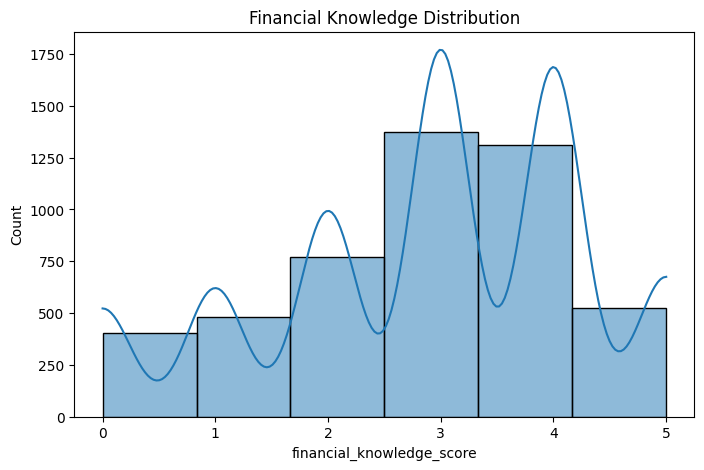

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data['financial_knowledge_score'], bins=6, kde=True)
plt.title("Financial Knowledge Distribution")
plt.show()

In [27]:
# EDUCATION ANALYSIS

In [28]:
### Average Score by Education
edu_analysis = data.groupby('education')['financial_knowledge_score'].mean()
edu_analysis

education
1     3.014493
2     3.309417
3     3.098253
4     3.186275
5     2.990533
6     2.510903
7     2.270609
8     1.614035
9     1.824176
10    0.190476
Name: financial_knowledge_score, dtype: float64

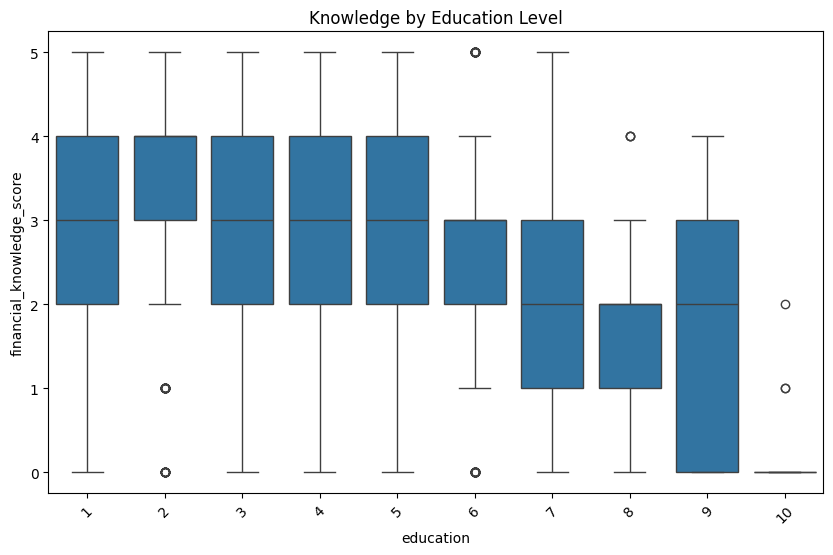

In [29]:
#Visualization
plt.figure(figsize=(10,6))
sns.boxplot(x='education', y='financial_knowledge_score', data=data)
plt.xticks(rotation=45)
plt.title("Knowledge by Education Level")
plt.show()

In [30]:
print(data.columns.tolist())

['gender', 'age', 'region', 'urban', 'education', 'employment', 'income', 'internet_access', 'qk3', 'qk4', 'qk5', 'qk6', 'qk10', 'qk3_correct', 'qk4_correct', 'qk5_correct', 'qk6_correct', 'qk10_correct', 'financial_knowledge_score']


In [31]:
gender_analysis = data.groupby('gender')['financial_knowledge_score'].mean()
gender_analysis

gender
0    2.729763
1    3.028560
Name: financial_knowledge_score, dtype: float64

In [32]:
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-29','30-39','40-49','50-59','60-69','70+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels)

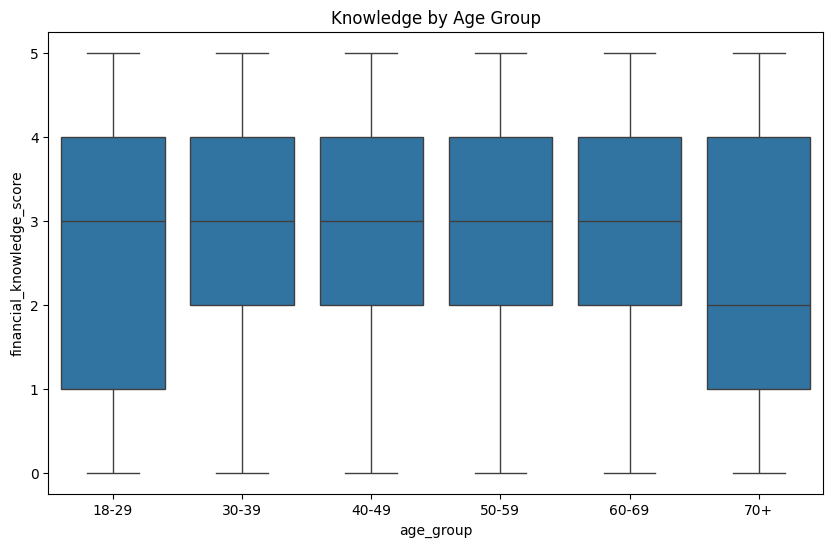

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='age_group', y='financial_knowledge_score', data=data)
plt.title("Knowledge by Age Group")
plt.show()

In [34]:
features = [
    'gender',
    'age',
    'education',
    'income',
    'internet_access'
]

In [35]:
reg_data = data[features + ['financial_knowledge_score']].dropna()

In [36]:
from sklearn.model_selection import train_test_split

X = reg_data[features]
y = reg_data['financial_knowledge_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import r2_score, mean_squared_error

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.08647439431696491
RMSE: 1.2960535399727449


In [40]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,gender,0.140064
1,age,0.004894
2,education,-0.138416
3,income,0.120893
4,internet_access,0.950379


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [42]:
y_pred

array([2.93235933, 3.4932467 , 1.58004062, 2.85619564, 3.05284598,
       3.21925428, 3.13605013, 3.61835401, 3.04003529, 3.34504172,
       2.94214806, 3.20008326, 3.3560227 , 2.98473135, 3.18215365,
       3.24266656, 3.5205586 , 3.23393736, 3.67054415, 3.25351481,
       3.13957036, 2.82985144, 3.31567555, 3.92033847, 3.40025383,
       3.83018569, 3.77497358, 3.33076507, 3.62854916, 3.10219603,
       3.21289395, 3.00604846, 3.28630938, 3.10855635, 2.94731612,
       3.19029454, 3.10571626, 2.99950626, 3.33173277, 3.27798662,
       3.23082357, 3.26183757, 2.01162032, 3.30099246, 3.39741374,
       1.8617675 , 2.09455077, 3.02700004, 3.66770406, 3.18988811,
       3.46525466, 3.15416162, 3.1315622 , 3.34014736, 2.40074945,
       2.93235933, 3.14583885, 3.59104211, 2.93930796, 3.45125171,
       3.62187424, 3.35661101, 3.51909264, 3.11363259, 2.91140775,
       3.0253522 , 3.59104211, 3.64469821, 3.17071709, 3.35739683,
       3.262244  , 3.37783629, 3.39741374, 1.61704942, 3.20919

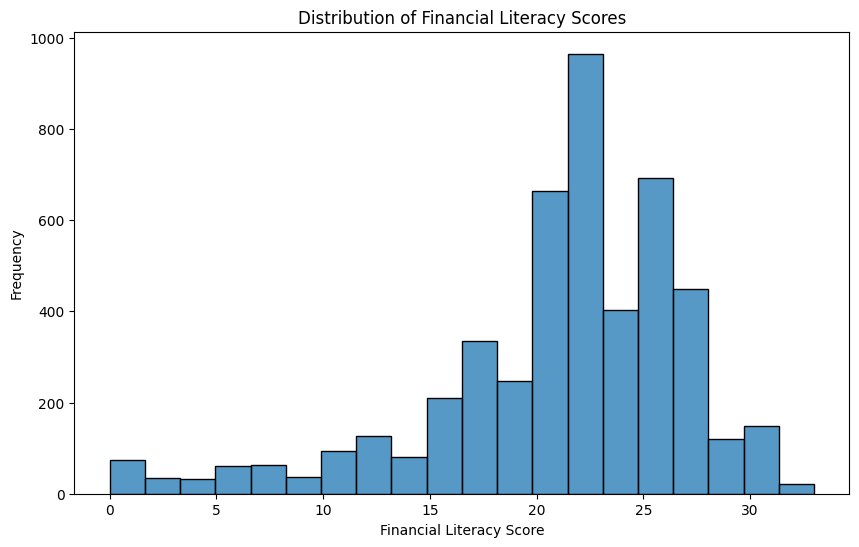

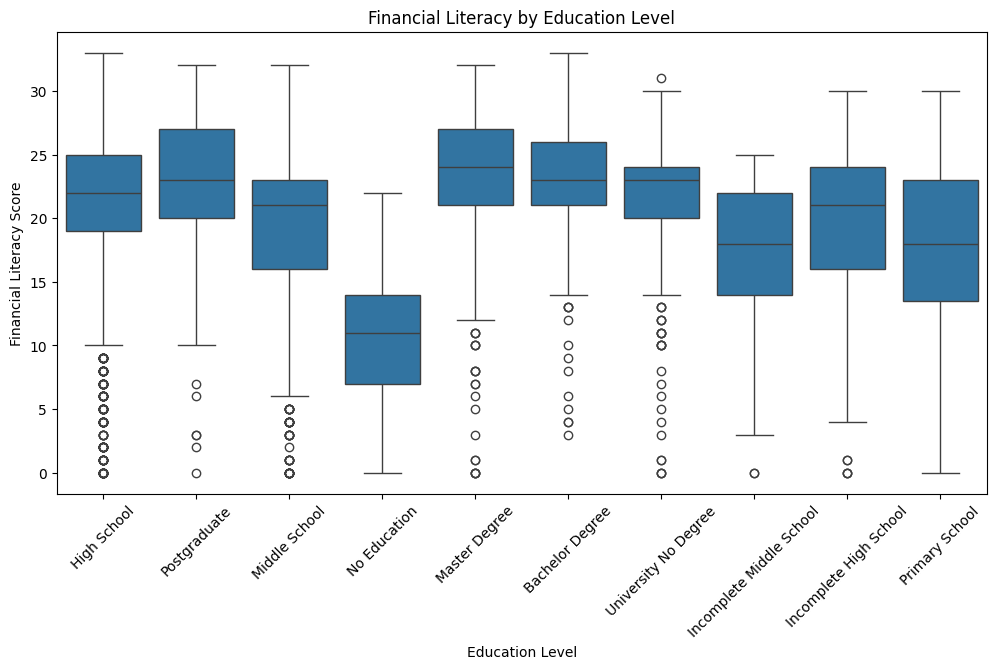

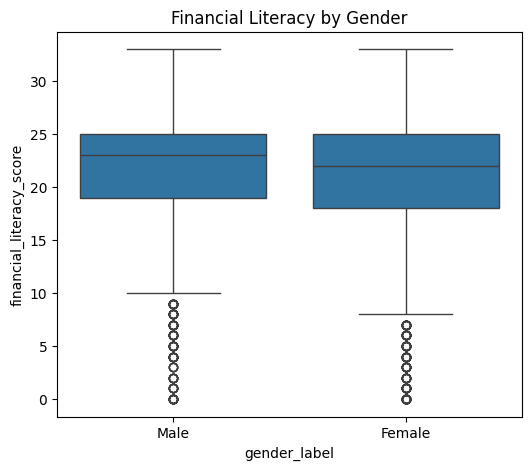

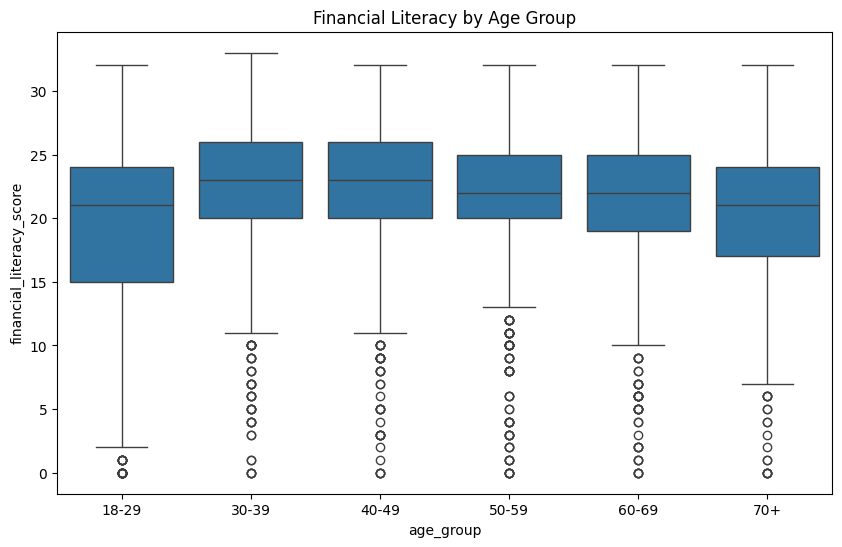

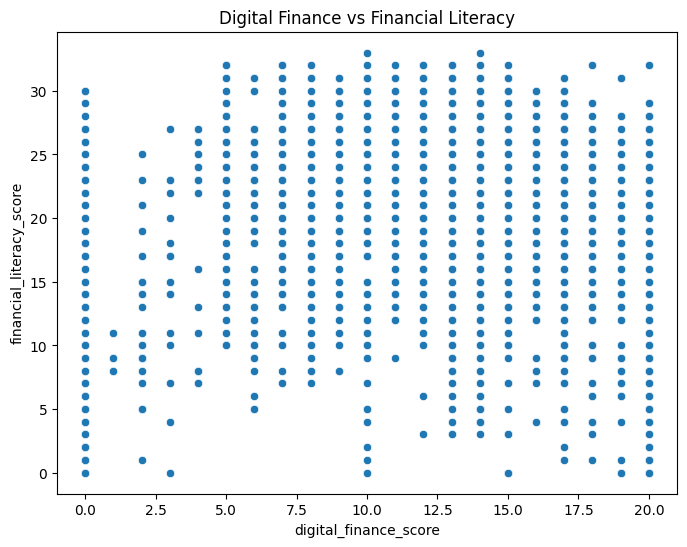

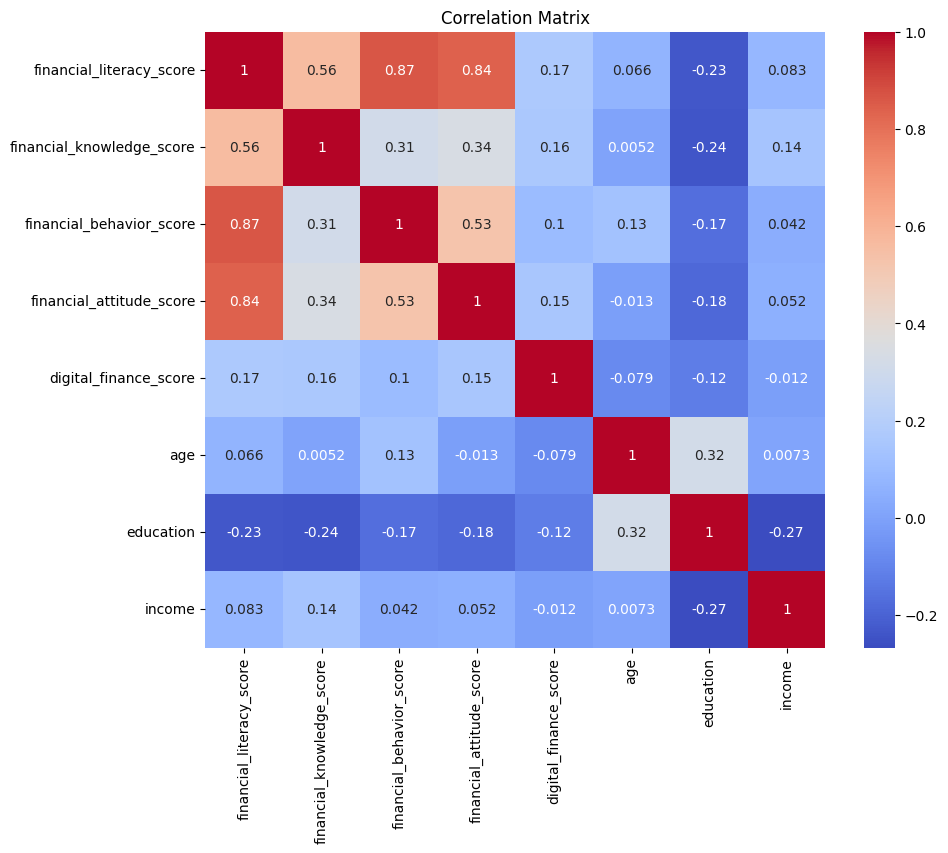

R² Score:
0.07711644044127552

RMSE:
5.127038452891446
                 Feature  Coefficient
0                 gender     0.693327
3                 income     0.180403
5  digital_finance_score     0.144276
1                    age     0.006226
4        internet_access    -0.146850
2              education    -0.736117


  File "C:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lenovo\anaconda3\Lib\subproc

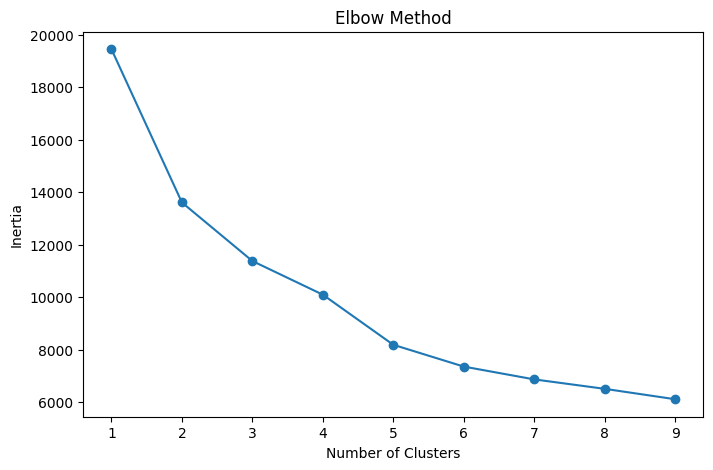

         financial_knowledge_score  financial_behavior_score  \
cluster                                                        
0                         1.622373                  9.772881   
1                         1.609842                  4.070299   
2                         3.791696                 10.929028   

         financial_attitude_score  digital_finance_score  
cluster                                                   
0                        8.661017              10.599322  
1                        2.551845               8.797891  
2                        9.548971              13.484031  


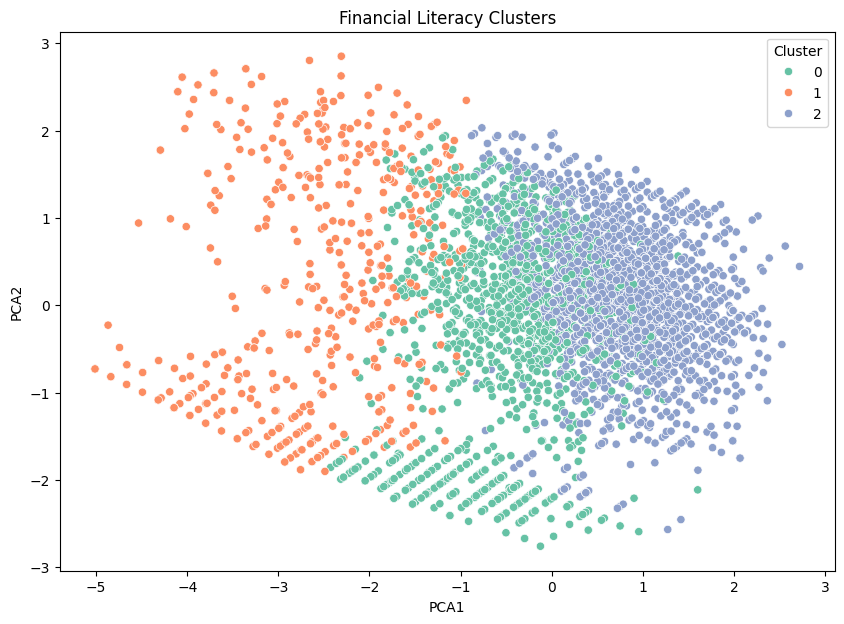


PROJECT COMPLETED SUCCESSFULLY

Dataset Shape:
(4862, 242)

All figures saved in:
figures/

Clean dataset saved as:
cleaned_financial_literacy_data.csv


In [4]:
# ============================================================
# BANK OF ITALY FINANCIAL LITERACY PROJECT
# COMPLETE CLEAN VERSION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 2. LOAD DATASET
# ============================================================

data = pd.read_stata("D://1 Univesrity work//Lect 2//Data Science Lab//Determinants-of-Financial-Literacy-Among-Italian-Adults-Evidence-from-the-IACOFI-2023-Survey//Dataset//Database_ENG.dta")

# ============================================================
# 3. REPLACE INVALID VALUES
# ============================================================

invalid_values = [-99, -98, -97, -999]

data.replace(invalid_values, np.nan, inplace=True)


# ============================================================
# 4. RENAME IMPORTANT COLUMNS
# ============================================================

data = data.rename(columns={

    'qd9': 'education',
    'qd7': 'age',
    'qd1': 'gender',
    'qd2': 'region',
    'qd3': 'urban',
    'qd10': 'employment',
    'qd13': 'income',
    'qd14': 'internet_access'

})


# ============================================================
# 5. CREATE FINANCIAL KNOWLEDGE SCORE
# ============================================================

# Correct answers:
# qk3 = 3
# qk4 = 0
# qk5 = 102
# qk6 = 1
# qk10 = 1

data['qk3_correct'] = (data['qk3'] == 3).astype(int)

data['qk4_correct'] = (data['qk4'] == 0).astype(int)

data['qk5_correct'] = (data['qk5'] == 102).astype(int)

data['qk6_correct'] = (data['qk6'] == 1).astype(int)

data['qk10_correct'] = (data['qk10'] == 1).astype(int)


knowledge_cols = [

    'qk3_correct',
    'qk4_correct',
    'qk5_correct',
    'qk6_correct',
    'qk10_correct'

]

data['financial_knowledge_score'] = data[
    knowledge_cols
].sum(axis=1)


# ============================================================
# 6. CREATE FINANCIAL BEHAVIOR SCORE
# ============================================================

# Reverse scale questions
# 1 = Always
# 5 = Never

behavior_reverse_cols = [

    'qs2_3',
    'qs2_5'

]

for col in behavior_reverse_cols:

    data[col + '_rev'] = 6 - data[col]


behavior_score_cols = [

    'qf2_1',
    'qf2_2',
    'qf2_4',
    'qf2_5',
    'qf3_2',

    'qs2_3_rev',
    'qs2_5_rev'

]

data['financial_behavior_score'] = data[
    behavior_score_cols
].sum(axis=1)


# ============================================================
# 7. CREATE FINANCIAL ATTITUDE SCORE
# ============================================================

attitude_cols = [

    'qs1_1',
    'qs1_5',
    'qs1_8'

]

for col in attitude_cols:

    data[col + '_rev'] = 6 - data[col]


attitude_score_cols = [

    'qs1_1_rev',
    'qs1_5_rev',
    'qs1_8_rev'

]

data['financial_attitude_score'] = data[
    attitude_score_cols
].sum(axis=1)


# ============================================================
# 8. FINAL FINANCIAL LITERACY SCORE
# ============================================================

data['financial_literacy_score'] = (

    data['financial_knowledge_score']
    + data['financial_behavior_score']
    + data['financial_attitude_score']

)


# ============================================================
# 9. CREATE DIGITAL FINANCE SCORE
# ============================================================

digital_cols = [

    'qp9_1',
    'qp9_3',
    'qp9_4',
    'qp9_5',
    'qp9_6'

]

for col in digital_cols:

    data[col + '_rev'] = 5 - data[col]


digital_score_cols = [

    col + '_rev'
    for col in digital_cols

]

data['digital_finance_score'] = data[
    digital_score_cols
].sum(axis=1)


# ============================================================
# 10. EDUCATION LABELS
# ============================================================

education_labels = {

    1: 'Postgraduate',
    2: 'Master Degree',
    3: 'Bachelor Degree',
    4: 'University No Degree',
    5: 'High School',
    6: 'Incomplete High School',
    7: 'Middle School',
    8: 'Incomplete Middle School',
    9: 'Primary School',
    10: 'No Education'

}

data['education_label'] = data[
    'education'
].map(education_labels)


# ============================================================
# 11. GENDER LABELS
# ============================================================

gender_labels = {

    1: 'Male',
    0: 'Female'

}

data['gender_label'] = data[
    'gender'
].map(gender_labels)


# ============================================================
# 12. AGE GROUPS
# ============================================================

bins = [18, 30, 40, 50, 60, 70, 100]

labels = [

    '18-29',
    '30-39',
    '40-49',
    '50-59',
    '60-69',
    '70+'

]

data['age_group'] = pd.cut(

    data['age'],
    bins=bins,
    labels=labels

)


# ============================================================
# 13. CREATE FIGURES FOLDER
# ============================================================

import os

os.makedirs('figures', exist_ok=True)


# ============================================================
# 14. DISTRIBUTION OF FINANCIAL LITERACY
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data['financial_literacy_score'],
    bins=20
)

plt.title('Distribution of Financial Literacy Scores')

plt.xlabel('Financial Literacy Score')

plt.ylabel('Frequency')

plt.savefig(
    'figures/literacy_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 15. EDUCATION VS FINANCIAL LITERACY
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(

    x='education_label',
    y='financial_literacy_score',
    data=data

)

plt.xticks(rotation=45)

plt.title(
    'Financial Literacy by Education Level'
)

plt.xlabel('Education Level')

plt.ylabel('Financial Literacy Score')

plt.savefig(
    'figures/education_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 16. GENDER ANALYSIS
# ============================================================

plt.figure(figsize=(6,5))

sns.boxplot(

    x='gender_label',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Financial Literacy by Gender'
)

plt.savefig(
    'figures/gender_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 17. AGE GROUP ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(

    x='age_group',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Financial Literacy by Age Group'
)

plt.savefig(
    'figures/age_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 18. DIGITAL FINANCE VS LITERACY
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x='digital_finance_score',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Digital Finance vs Financial Literacy'
)

plt.savefig(
    'figures/digital_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 19. CORRELATION HEATMAP
# ============================================================

correlation_vars = [

    'financial_literacy_score',
    'financial_knowledge_score',
    'financial_behavior_score',
    'financial_attitude_score',
    'digital_finance_score',
    'age',
    'education',
    'income'

]

plt.figure(figsize=(10,8))

sns.heatmap(

    data[correlation_vars].corr(),
    annot=True,
    cmap='coolwarm'

)

plt.title('Correlation Matrix')

plt.savefig(
    'figures/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 20. REGRESSION MODEL
# ============================================================

features = [

    'gender',
    'age',
    'education',
    'income',
    'internet_access',
    'digital_finance_score'

]

regression_data = data[
    features + ['financial_literacy_score']
].dropna()

X = regression_data[features]

y = regression_data[
    'financial_literacy_score'
]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R² Score:")

print(
    r2_score(y_test, predictions)
)

print("\nRMSE:")

print(
    np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
)


# ============================================================
# 21. REGRESSION COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({

    'Feature': features,
    'Coefficient': model.coef_

})

print(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))


# ============================================================
# 22. CLUSTERING ANALYSIS
# ============================================================

cluster_cols = [

    'financial_knowledge_score',
    'financial_behavior_score',
    'financial_attitude_score',
    'digital_finance_score'

]

cluster_data = data[
    cluster_cols
].dropna()


# ============================================================
# STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)


# ============================================================
# ELBOW METHOD
# ============================================================

inertia = []

K = range(1,10)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)


plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.savefig(
    'figures/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FINAL KMEANS MODEL
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    scaled_data
)

cluster_data['cluster'] = cluster_labels


# ============================================================
# CLUSTER SUMMARY
# ============================================================

cluster_summary = cluster_data.groupby(
    'cluster'
).mean()

print(cluster_summary)


# ============================================================
# PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_data
)

cluster_plot = pd.DataFrame({

    'PCA1': pca_result[:,0],
    'PCA2': pca_result[:,1],
    'Cluster': cluster_labels

})


plt.figure(figsize=(10,7))

sns.scatterplot(

    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=cluster_plot,
    palette='Set2'

)

plt.title(
    'Financial Literacy Clusters'
)

plt.savefig(
    'figures/clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 23. SAVE CLEAN DATASET
# ============================================================

data.to_csv(
    'cleaned_financial_literacy_data.csv',
    index=False
)


# ============================================================
# 24. FINAL CHECK
# ============================================================

print("\nPROJECT COMPLETED SUCCESSFULLY")
print("\nDataset Shape:")
print(data.shape)

print("\nAll figures saved in:")
print("figures/")

print("\nClean dataset saved as:")
print("cleaned_financial_literacy_data.csv")


In [ ]:
Greetings Professor,
I hope this email finds you well. I'm writing to request your guidance on our Data Management project. We initially had an approved project, but as we progressed, we realized it did not fully satisfy the course requirements according to your guidelines. 
We then developed two new projects that properly cover all the required phases of the Data Management. We have worked hard to implement all phases and ensure reproducibility, quality, and meaningful analysis. At this stage, we would greatly appreciate your advice in choosing which project to submit as the final work.

Option 1: Global Mental Health and Socioeconomic Data Integration and Analysis
Main Idea: Analyze how mental health trends vary across countries and years, and how they relate to socioeconomic factors such as income, unemployment, and education.
Data Sources:Mental health data from WHO API Socioeconomic indicators from World Bank API
What we did: 
Collected and cleaned data from both sources, resolved inconsistencies, integrated datasets by country and year, stored the final dataset in SQLite, and analyzed trends to answer key questions.
Research Questions: How do mental health trends vary across countries and years?Are mental health outcomes correlated with socioeconomic factors such as unemployment, income, or education?Which countries have shown the greatest improvement or decline in mental health over the past decade?Do socioeconomic factors explain differences in mental health trends between high-income and low-income countries?
"
i want you to write project proposal this is mail pattern you can follow or you can write imporve mail so the content is below "

"this is professor guiidance below "

HOW TO SUBMIT THE REPORT
The delivery has to be done in this way, otherwise it won’t be considered:
1. sent by email from university accounts of one of the group’s members (@campus.unimib.it)
2. sent to (field “To:”) both marco.fattore@unimib.it and silvio.gerli@unimib.it
3. with all the members of the group in the “Cc:” field
4. with subject: "DELIVERY DSLAB 2026" and then all the surnames of the students in the group
5. in attachment: the file with the report in pdf
6. Optional: the file(s) with the code for reproducibility in attachment or linked in the body
7. in the body the list of the names and surnames of all the members of the group with their “matricola” numbers
8. sent it at least 10 days before the last date of the exam session

You can send your reports when you like; they will be assessed for the first available session, according to the following general rule: reports received >10 days before the exam date will be assessed for that session (but this depends upon the number of reports received, in a single session). Otherwise, they will be assessed for subsequent sessions.


LENGTH OF THE REPORT
Do not send report of 4/5 pages
Max length 20 pages.
Font: Arial or similar (easy to read).
Character dimension (main text): 11pt.


REPORT SCHEME
The following scheme specifies the required structure of the report. Obviously, some elasticity is accepted, based on the nature and the features of the project. Anyway, try to stick to the scheme and to its spirit. Avoid purely technical reports (e.g. mainly based on implementing batteries of alternative algorithms, comparing tons of performance indicators, just to select the best performing tool. Start by identifying a "good question", one which is relevant to some stakeholder, and try to answer it, motivating all of the steps you take. The reports will not be evaluated based on the "exceptionality" of the results, but on the relevance of the question and the soundness of the way it is addressed (also "negative/problematic answers" can be ok, e.g. "The question is relevant, the data are all those available, but it is hard to answer the question, so maybe new data should be collected...".). Needless to say, be realistic: do not pursue goals for which data are evidently insufficient or not adequate. 

1. Title
2. Authors' details (Family name, First name, Badge number, email)
3. Keywords (maximum 5)
4. Name of the dataset, chosen for the project.
5. Declaration: do you have used AI tools? and, if yes, where and how?

6. Abstract (max 15 rows): a synthesis of the aims of the study, of the methodologies employed and of the results.

7. Research question
7a Statement (providing all of the necessary definitions and concepts)
7b Motivation and stakeholders/users (i.e. for whom should your study be of    interest?)

8. The Data
8a. Data description
8b. Comments on the strength or weakenesses of the data, with respect to the goal of the study.

9. Methodology
9a. The overall logic thread of the study.
9b. The tools: which and why.

10. Results
10a. The steps of the study: description and essential numbers/pictures…
10b. Comments and interpretation.

11. Conclusion
Gap between the goal and the results
Strengths/weaknesses of the study
Directions for further research or improvements.

12. References
Bibliographic list of the sources (papers data, websites…). These must be numbered and cited in the text, when needed.

Appendix (if needed)
Detailled outputs
Sw scripts
...



The projects MUST be developed based on one of the following sources.
The first three websites conmprise many different datasets, within the same topic (e.g. different sustainability domains). You can choose freely, within these contexts.
Some datasets are huge and complex. Your are not required to perform exhaustive studies of the underlying topics. You can choose a subset of the dataset, and focus on a specific question. Your study must be consistent with the goal of the exam, it is not supposed to be a "master thesis". Data documentation can be found in the same websites.

OECD WELLBEING
https://www.oecd.org/en/data/tools/well-being-data-monitor.html

OECD SUSTAINABILITY
https://data-explorer.oecd.org/vis?lc=en&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_SDG%40DF_SDG_G_1&df[ag]=OECD.WISE.RSB&dq=..1_2..._T._T._T._T._T.&lom=LASTNPERIODS&lo=5&to[TIME_PERIOD]=false

VDEM data (democracy data)
https://www.v-dem.net/data/

Financial literacy Bank of Italy
https://www.bancaditalia.it/statistiche/tematiche/indagini-famiglie-imprese/alfabetizzazione/index.html?com.dotmarketing.htmlpage.language=1


"I choce one of dataset from  his descripestion is below "


the file are in .dta

Surveys on Financial Literacy and Digital
Financial Skills in Italy: Adults
Questionnaire IACOFI 2023*
Personal and household characteristics
RECORD OR ASK ALL
Gender Question: QD1
Label: Gender
Male 1
Female 0
Other answer -98
Refused -99
ASK ALL
Please could you tell me how old you are, currently? Question: QD7
Label: Age
Age: Minimum value='18'
Refused -99
 ask IF QD7=-99
Would you {instead} tell me which of these age bands you fall into? Question: QD7_a
Label: Age bands
18-19 1
20-29 2
30-39 3
40-49 4
50-59 5
60-69 6
70-79 7
Refused -99
RECORD OR ASK ALL
Macro-region Question: QD2
Label: Region
North-West 1
North-East 2
Center 3
South 4
Islands 5

* See OECD (2022), OECD/INFE Toolkit for Measuring Financial Literacy and Financial Inclusion 2022
2
RECORD ALL OR ASK ALL.
Could you tell me which of these best describes the community you currently live in, please? Question: QD3
Label: Urban
A village, hamlet or rural area (fewer than 3 000 people) 1
A small town (3 000 to about 15 000 people) 2
A town (15 000 to about 100 000 people) 3
A city (100 000 to about 1 000 000 people) 4
A large city (with over 1 000 000 people) 5
ASK ALL
Who do you usually live with in your household? Do you live… Question: QD5
1='Yes' 0=No.
Labels: Household
Entirely alone [STOP READING IF YES] _1
With a partner/spouse _2
With children under the age of 18 _3
With children aged 18 or over _4
With other adult relatives _5
With friends, colleagues or students _6
With other adults; not related _7
Refused to answer the entire question _99
ASK if QD5_1=0 (if respondent does not live alone)
How many adults (aged 18 or over) live in your household, including yourself? Question: QD5_ad
Labels: Household count_
Record response [Minimum value=1]
Does not apply -98
Refused to answer -99
ASK if QD5_1=0 (if respondent does not live alone) AND QD5_3=1 (if respondent lives with children under
the age of 18)
How many children under the age of 18 live in your household? Question: QD5_ch
Labels: Household count_
Record response [Minimum value=1]
Does not apply -98
Refused to answer -99
ASK ALL
And which of these best describes your current work situation? Please refer to your main working status Question: QD10
Label: Work situation
Self-employed [work for yourself] 1
In paid employment [work for someone else] 2
Apprentice 3
3
Looking after the home 4
Looking for work [unemployed] 5
Retired 6
Unable to work due to sickness or ill-health 7
Not working and not looking for work 8
Student 9
Other 10
Refused -99
ASK ALL
Do you have access to the internet? Question: QD14
Label: Internet
Yes 1
No 0
Refused -99
Planning and managing finances
ASK ALL
Do you make day-to-day decisions about your own money? Question: QF1_a
Label: Personal budget
Yes 1
No 0
Don’t know -97
Refused -99
ASK ALL
And who is responsible for making day-to-day decisions about money in your household? Question: QF1
Label: Decisions
You make these decisions by yourself 1
You make these decisions with someone else 2
Someone else makes these decisions 3
Don’t know -97
Refused -99
ASK ALL
Do you do any of the following for yourself or your household? Question: QF2
1='Yes,' 0='No,' -99=Refused
Label: Budget
Make a plan to manage your income and expenses _1
Keep a note of your spending _2
Keep money for bills separate from day-to-day spending money _3
Make a note of upcoming bills to make sure you don't miss them _4
Use a banking app or money management tool to keep track of your outgoings _5
Arrange automatic payments for regular outgoings _6
4
Active saving and financial shocks
ASK ALL
In the past 12 months have you been [personally] saving money in any of the following ways, whether or not you
still have the money? Please don't take into account any money paid into a pension, but think about all kinds of
savings, such as building up a rainy-day fund or putting money aside for a special occasion.
Question: QF3
1='Yes,' 0='No,' -99=Refused.
Labels: Active
saving
Saving cash at home or in your wallet _1
Paying money into a <savings/deposit> account _2
Giving money to family to save on your behalf _3
Saving in <an informal savings club> _4
Buying bonds or time deposits _5
Investing in crypto-assets _6
Investing in stocks and shares _7
Saving or investing in some other way, other than a pension
(INTERVIEWER: examples can be given, possibly including remitting money to be invested in home country, or buying
livestock, gold, real estate or other property)
_8
I bought other financial instruments (e.g. investment accounts, loans to cooperatives) _81
I did not save _98
ASK ALL
If you, personally, faced a major expense today – equivalent to your own monthly income – would you be able to
pay it without borrowing the money or asking family or friends to help?
[Add if necessary, if you do not currently have an income, please think about an unexpected expense equivalent
to the amount of money you typically spend in a month.]
Question: QF4
Label: Expenditure
shock
Yes, with money immediately available 1
Yes, selling assets 2
No 0
Don’t know -97
Not applicable (I don't have any personal income) -98
Refused -99
Retirement plans
 ASK ALL
[to retired] Overall, on a scale of 1 to 5 where 1 is very confident, and 5 is not at all confident; how confident
are you that you have done a good job of making financial plans for your retirement?
[to non-retired] Overall, on a scale of 1 to 5 where 1 is very confident, and 5 is not at all confident; how
confident are you that you are doing a good job of making financial plans for your retirement?
Question: QF8
1='very' confident, 2, 3, 4, 5='not' at all confident
Label: Retirement
confidence
Very confident 1
2 2
3 3
4 4
Not at all confident 5
Respondent has no retirement plan 6
Don’t know -97
Refused -99
5
ASK ALL
and how will you - or do you - fund your retirement? Question: QF9
1='Yes,' 0='No,' -97 Don't know, -99=Refused.
Labels: Retirement
plans_
Draw a government pension/ old-age benefit _1
Draw an occupational or workplace pension plan _2
Draw a private pension plan _3
Sell your financial assets (such as: stocks, bonds or mutual funds) _4
Sell your non-financial assets (such as a car, property, art, jewels, antiques, etc.) _5
From income generated by your financial or non-financial assets
(such as dividends or rental income)
_6
Rely on a spouse or partner to support you _7
Rely on your children or other family members to support you _8
Draw on your savings _9
Continue to work 10
From the revenues of a business that you own 11
Reversibility pension _12
Making ends meet
ASK ALL
Sometimes people find that their income does not quite cover their living expenses. In the last 12 months,
has this happened to you, personally?
Question: QF11
Label: Not covering
costs
Yes 1
No 0
Don’t know -97
Not applicable (I don't have any personal income) -98
Refused -99
ASK only if QF11=1
What did you do to make ends meet the last time this happened? Question: QF12
1='Yes,' 0=No, -98= Not applicable, - 97 = Do not know.
Labels: Making ends
meet
_1 Existing resources
Draw money out of savings or transfer savings into <current> account _1_1
Cut back on spending, spend less, do without, delay a planned expense _1_2
Sell something that you own _1_3
_2 Additional resources
Work overtime, take an extra job, earn extra money _2_1
Claim support from the government _2_2
Ask for help from family, friends or the community _2_3
_3 Access credit by using existing contacts or resources
Borrow from family, friends or the community _3_1
Borrow from employer/salary advance _3_2
Pawn something that you own _3_3
6
Take a loan from your savings and loans clubs or other <informal savings club> _3_4
Use someone else’s credit card _3_5
Take money out of a flexible mortgage account _3_6
Apply for loan/withdrawal on pension fund _3_7
_4 Borrow from existing credit line
Use authorised, arranged overdraft or line of credit _4_1
Use credit card for a cash advance or to pay bills/buy food _4_2
_5 Access additional credit
Take out a personal loan from a financial service provider (including bank, credit union or microfinance) _5_1
Take out a payday loan _5_2
Take out a loan from an informal provider/moneylender _5_3
Take an SMS loan _5_4
Take an online <instant cash> loan _5_5
_6 Fall behind/ go beyond arranged amount
Use unauthorised overdraft _6_1
Pay bills late; miss payments _6_2
_7 Other responses
Other _7_1
Don’t know _97
Refused _99
ASK ALL
If you lost your main source of income today, how long could you continue to cover your living expenses,
without borrowing any money or moving house?
Question: QF13
1='less' than a week, 2, 3, 4, 5='6' months or more
Label: Lost income
a) Less than a week 1
b)At least a week, but not one month 2
c) At least one month, but not three months 3
d) At least three months, but not six months 4
e) Six months or more 5
Don’t know -97
Refused -99
7
Choosing and using financial products and services
ASK ALL
Questions: QP1 / QP2 / QP3
Labels: Heard of [followed by product]; Currently holds [ ]; Recently chosen [ ].
1='Yes,' 0='No,' -97='Don’t' know (only for QP3),
-99=Refused (only for QP2 and QP3)
.
ASK ALL Please
can you tell me
whether you have
heard of any of
these types of
financial products
ASK IF QP1=Yes and
now can you tell me
whether you
[personally or jointly]
currently hold any of
these types of products
ASK IF QP1=Yes.
and in the last two years, which of
the following types of financial
products have you chosen
[Personally or jointly] whether or not
you still hold them… Please do not
include products that were renewed
automatically
A pension or retirement product _1 _1 _1
An investment account _2 _2 _2
A mortgage or home-loan _3 _3 _3
An unsecured bank loan _5 _5 _5
A credit card _7 _7 _7
A current/checking/payment account _8 _8 _8
A savings account _9 _9 _9
Insurance _11 _11 _11
Stocks and shares _12 _12 _12
Bonds _13 _13 _13
Mobile/cell phone payment account [not directly
linked to a bank account]
_14 _14 _14
A prepaid debit card/ payment card [not directly
linked to a bank account]
_15 _15 _15
Crypto-assets _16 _16 _16
Financial products labelled as sustainable, or
“ESG”, or “green” [Note to agency: This may
include investments, pensions, mortgages,
bonds, etc. and does not replace other items
inthe list asking about these products more
generally]
_17 _17 _17
Loan granted for the purchase of a specific good or
service (car, household appliance, furniture,
holidays etc.)
_add_1 _add_1 _add_1
Loans to cooperatives (COOP, social loans, etc.) _add_2 _add_2 _add_2
Service ‘Buy Now Pay Later’ _add_3 _add_3 _add_3
Insurance to protect against unforeseen events in
the repayment of loans
_add_4 _add_4 _add_4
Basic Account (limited operation account, with no or
limited fees for access to some types of operations
and fundamental payment services)
_add_5 _add_5 _add_5
None _98 _98 _98
8
ASK ALL THOSE WHO ANSWERED YES AT ANY OF QP3.
and which of the following statements best describes how you made your most recent choice? Question: QP5
Label: Shopping around
I considered several options from different companies before making my decision 1
I considered various options from one company 2
I didn’t consider any other options at all 3
I looked around but there were no other options to consider 4
Don’t know -97
Not applicable -98
Refused -99
ASK ALL THOSE WHO ANSWERED YES AT ANY OF QP3
and which of these sources of information do you feel significantly influenced your decision {about which one to
take out}?
Question: QP7
1='Yes,' 0=No,-97='Don’t' know, -98 Not relevant, -99=Refused.
Label: Information
source
Specialist product comparisons or best-buy guidance (such as specialist magazines) _1
A price comparison website _2
A recommendation from an independent financial advisor [Note to agency: if necessary clarify that independent advisors
are fee-based, and should not include commission-based ones]
_3
Information from an advert or <brochure> about this specific product _4
A recommendation from friends, family or acquaintances _5
A recommendation from people you do not know (such as social media or “influencers”) _6
Information provided by staff of the financial product provider (in person, online or over the phone) _7
Advertising on TV, radio or non-specialized newspaper or on the internet _81
Other sources _82
Refused the entire question _99
ASK ALL
In managing financial investments, you believe you are a person more oriented
towards investments that offer the possibility of:
Question: QP7_add1
Label: Risk adversion
very high earnings, despite a high risk of losing part of the capital 1
a good profit, but at the same time a fair degree of safety of the invested capital 2
a decent profit, but at the same time a good degree of safety of the invested capital 3
low earnings, without any risk of capital loss 4
Refused -99
ASK IF QD14=1
Have you ever done any of the following? Question: QP8
1='Yes,' 0='No,' -97='Don’t' know. -98 not applicable, -99=Refused Label: have you done
the following
activities?
Opened a <current/payment> account or <savings/deposit> account completely online _1
Requested a payment, debit or credit card completely online _2
Subscribed to an insurance policy completely online _3
Taken out credit completely online _4
Invested money via online platforms (crowdfunding, crowd investing, peer-to-peer lending) _5
9
ASK IF QD14=1
In the last 12 months, how often have you done the following? Question: QP9
1='Never,' 2='Sometimes,' 3='Often',4='Very often' -97='Don’t' know. -98 =Not applicable, -99=Refused Label: how often have
you done the
following?
Checked the balance and transactions of my bank account online _1
Paid bills online _3
Bought goods and services online _4
Transferred money to others online [note to agency: this should not include money sent through agents] _5
Managed financial products and services (such savings, investments, credit, insurance) online _6
Paid for goods and services in a physical shop with a mobile phone (e.g. using a mobile wallet, such as Apple Pay, Google
Pay…)
_7
Consulted an online platform for automated financial advice (roboadvisor) _10
ASK ALL
Thinking about financial products and services in general, in the last 2 years, have you experienced any of the
following issues?
Question: QP10
1='Yes,' 0='No,' -95='Don’t' understand the question, -97='Don’t' know, -98 Not relevant,-99=Refused
Label: Issues
{Have you} accepted advice to invest in a financial product that you later found to be a scam, such as a <pyramid> scheme? _1
{Have you} accidently provided personal financial information (such as passwords or card number) in response to an email,
phone call or social media message that you later found out was not genuine?
_2
{Have you} discovered that someone has used your <card> details to pay for goods without your authorisation? _3
{Have you} queried a transaction listed on your bank or credit card statement that you did not recognise? _4
{Have you} made a formal complaint about the service you have received from a bank or other financial institution? _5
{Have you} been denied credit for which you had applied? _8
{Have you} complained to a remittance provider about high charges when sending or receiving money? _9
Financial knowledge
ASK ALL
Thank you. And, now something slightly different. Could you tell me how you would rate your overall knowledge
about financial matters compared with others?
Question: QK1
1='very' high, 2, 3, 4, 5='very' low
Label: Self-rated knowledge
a) Very high 1
b) Quite high 2
c) About average 3
d) Quite low 4
e) Very low 5
Don’t know -97
Refused -99
 ASK ALL
Five brothers receive 1,000 euros today. Imagine they have to wait for one year to get their share of the
1,000 euros and that inflation stays at 8%*. In one year’s time will they be able to buy:
Question: QK3
Label: Brothers have to wait for
one year with inflation at
8%
a)More with their share of the money than they could today 1
b)The same amount; or 2
c)Less than they could buy today 3
d) It depends on the types of things that they want to buy 4
10
Don’t know -97
Irrelevant answer -999
*Source: Istat – National Consumer Price Index
 ASK ALL
You lend $25 to a friend one evening and he gives you $25 back the next day. How much interest
has he paid on this loan?
Question: QK4
Label: Interest on loan
OPEN RESPONSE
Don’t know -97
Irrelevant answer -999
ASK ALL
Imagine that someone puts 100 euro into a no fee savings account with a guaranteed interest rate of 2% per
year. They don’t make any further payments into this account and they don’t withdraw any money. How
much would be in the account at the end of the first year, once the interest payment is made?
Question: QK5
Label: Simple interest
Record Response [Minimum value=0]
Don’t know -97
Refused -99
Irrelevant answer -999
ASK ALL
and how much would be in the account at the end of five years if no other operations are carried out
on this account, neither deposits nor withdrawals, there are no fees and it continues to be
remunerated at a guaranteed interest rate of 2% per year? Would it be:
Question: QK6
Label: Compound
interest
a) More than 110 euro 1
b) Exactly 110 euro 2
c) Less than 110 euro; or is it 3
d) Impossible to tell from the information given 4
Don’t know -97
Irrelevant answer -999
 ASK ALL
I would like to know whether you think the following statements are true or false Question: QK7
1=True, 0='False,' -97='Don’t' know, -99=Refused
Label QK7_
An investment with a high return is likely to be high risk _1
High inflation means that the cost of living is increasing rapidly _2
It is usually possible to reduce the risk of investing in the stock market by buying a wide range of stocks and shares _3
A digital financial contract requires signature of a paper contract to be considered valid _4
The personal data that I share publicly online may be used to target me with personalised commercial or financial offers _5
Crypto-currencies have the same legal tender as banknotes and coins _6
11
ASK ALL
A 15-year mortgage usually has a higher monthly payment than a 30-year mortgage, but the
overall interest paid over the life of the loan is lower.
Question: QK10
Label: mortgage
a) True 1
b) False 0
Don’t know -97

Attitudes and behaviour
ASK ALL
I am now going to read out some statements. I would like to know how much you agree or disagree with each of these
statements (as it relates to you)
Question: QS1
1='completely' agree, 2, 3, 4, 5 completely disagree. -97='Don’t' know, -98 Not relevant,
-99=Refused.
Label: How much do you
agree with the following
statements?
I find it more satisfying to spend money than to save it for the long term _1
I am prepared to risk some of my own money when saving or making an investment _2
Money is there to be spent _3
I am satisfied with my present financial situation _4
I keep a close personal watch on my financial affairs _5
My financial situation limits my ability to do the things that are important to me _7
I set long term financial goals and strive to achieve them _8
I believe that money in a bank will be safe even if the bank fails _9
I have too much debt right now _10
I believe it’s the right moment to invest in crypto-assets or ICOs _13
ASK ALL
And how often would you say this statement applies to you?
For each statement could you tell me whether it Always, often, sometimes, rarely or never applies to you?
Question: QS2
1='Always,' 2, 3, 4, 5='Never,' -97='Don’t' know, -98 Not relevant, or -99=Refused.
Label: How often do the
statements apply to you?
I tend to worry about paying my normal living expenses _1
My finances control my life _2
Before I buy something I carefully consider whether I can afford it _3
I have money left over at the end of the month _4
I pay my bills on time _5
I share the passwords and PINs of my bank account with my close friends _6
Before buying a financial product online I check if the provider is regulated in my country _7
I share information about my personal finances publicly online (e.g. on social media) _8
Before I buy something I consider whether the company strives to improve its social or environmental impact _9
12
ASK ALL
I would also like to know how well this statement describes you or your situation.
For each statement could you let me know whether it describes your situation or thoughts completely, very well, somewhat,
very little or not at all.
Question: QS3
1='completely,' 2, 3, 4, 5='not' at all, -97='Don’t' know, -98 Not relevant, or -99=Refused.
Label: How well do the
following statements
describe you?
I prefer to choose financial intermediaries who make choices based on ethics (investments in clean
energy, exclusion of investments in companies that do not respect international arms treaties...)
_2
Because of my money situation, I feel like I will never have the things I want in life _3
I am concerned that my money won’t last _9
I am just getting by financially _10
I tend to live for today and let tomorrow take care of itself _11
I sometimes buy a lottery ticket when I feel like I don't have enough money _12
I regularly change the passwords on websites that I use for online shopping and personal finances _13
ASK IF QD14=1
I am now going to read out some statements. I would like to know how much you agree or disagree with each
of these statements (as it relates to you). Please use a scale of 1 to 5, where: 1 tells me that you completely
agree with the statement, and5 shows that you completely disagree
Question: QS4
1='completely' agree, 2, 3, 4, 5 completely disagree. -97='Don’t' know, -98 Not relevant -99=Refused.
Label: How much do you
agree with the following
statements?
I think that it is safe to shop online using public Wi-Fi networks (e.g., in cafés, airports, shopping malls) _1
It is important to pay attention to the security of a website before making a transaction online (e.g. https sites, safety logo
or certificate)
_2
I think it is not important to read the terms and conditions when buying something online _3
Digital tools facilitate the management of my personal finances _4
I trust the financial services provided by online banks and FinTechs _5
I believe that financial service providers should use a wide range of non-financial personal data, including from social
media, in decisions about granting credit
_6
I am more likely to buy impulsively when I buy online than in person in a shop _7
It is more likely that I would read the small print of a contract if it is on paper than online _8
ASK ALL
I am now going to read out some statements. I would like to know how much you agree or disagree with each of
these statements (as it relates to you). Please use a scale of 1 to 5, where: 1 tells me that you completely agree with
the statement, and5 shows that you completely disagree
Question: QS5
1='completely' agree, 2, 3, 4, 5 completely disagree. -97='Don’t' know, -98 Not relevant, -99=Refused.
Label: How much do
you agree with the
following statements?
It is more important to invest in companies that are making a profit than in companies that strive to minimise their negative
impact on the environment
_4
It is more important to invest in companies that are making a profit than in companies that strive to improve their social
impact
_5
It is more important to invest in companies that are making a profit than in companies that strive to improve their risk
management, ethics and accountability
_6
13
 Background information
 ASK ALL
In the last 12 months, how often have you done the following? Question: QD6
1='Never,' 2='Sometimes,' 3='Often', 4='Very often' -97='Don’t' know. -99=Refused
Label: How often have you
done the following?
Written document on a personal computer (desktop or laptop) _1
Sent or received an email _2
Used a mobile phone to make calls _3
Made calls over the internet (including video calls) _4
Participated in social networks online (such as <national examples>) _5
Used instant messaging applications (such as <national examples>) _6
Looked for information online (such as reading the news or finding information about goods and services) _7
ASK ALL
What is the highest level of education that you have completed? Question: QD9
Label: Educational level
Post-graduate education or equivalent (e.g. master’s degree, PhD or advanced professional training) 1
Second-cycle qualification (laurea magistrale, magistrale a ciclo unico) 2
Bachelor of arts (laurea triennale) 3
Attended university but did not graduate 4
High school diploma (upper secondary school) 5
Attended high school but did not complete 6
Middle school diploma (lower secondary school) 7
Attended middle school but did not complete 8
Primary school diploma 9
Primary school but did not complete, or no education 10
Refused -99
ASK ALL
What is your nationality? Question: QD12
Label: Place of birth
Italian 1
Other 0
Refused -99
ASK ALL
And finally, could you tell me which of these categories your household income usually falls into
(after tax)? Would you say it is…
Question: QD13
Label: Income band
a) Up to 1750 euro a month 1
b) Between 1751 euro and 2900 euro a month; or 2
c) more than 2900 euro a month 3
Don’t know -97
Refused -99
Financial literacy of Italian adults
Share
Stampa la pagina




Banca d'Italia has been conducting a triennial survey on the financial literacy in Italy (IACOFI) since 2017. The survey is based on a methodology developed by the International Network on Financial Education (INFE) of the OECD. In the 2023 edition, questions assessing the digital financial skills of respondents, measured using the OECD methodology, were introduced for the first time.
Financial literacy is measured by a comprehensive indicator that aggregates three dimensions: knowledge, behaviour, and attitudes.
The raw data are distributed anonymously for research purposes. Users bear full and exclusive responsibility for the use of the data, for which Banca d'Italia accepts no responsibility. The data are available in ASCII (Comma Separated Values), SAS and Stata formats.
Sezione di approfondimento
2023 Survey
The survey on Italy involved a sample of just under 5,000 individuals aged 18 to 79. The data collection took place in (the months of) February and March using Computer-Assisted Telephone Interviewing (CATI). The main results are presented in the report "Surveys on Financial Literacy and Digital Financial Skills in Italy: Adults", by S. Lamboglia, M. Marinucci, M. Stacchini, and P. Vassallo, Banca d'Italia. The results of the international comparison are published by the OECD on the webpage OECD/INFE 2023 International Survey of Adult Financial Literacy.
Publish date::29 May 2024
Data description 
pdf 513 KB


Publish date::30 May 2024
Database - STATA 
zip 266 KB


Publish date::30 May 2024
Database - ASCII 
[zip 293 KB
](https://www.bancaditalia.it/statistiche/tematiche/indagini-famiglie-imprese/alfabetizzazione/Database_ASCII_EN.zip?language_id=1)"below is dataset name where i work "[

](https://www.bancaditalia.it/statistiche/tematiche/indagini-famiglie-imprese/alfabetizzazione/Database_ASCII_EN.zip?language_id=1)


the dataset name is database_eng.dta 

below i code and research question 


Financial Literacy Among Italian Adults
Or
Determinants of Financial Literacy Among Italian Adults: The Role of Demographic, Educational, and Digital Factors
 
Research question
To what extent do demographic, educational, and digital factors explain differences in financial literacy among Italian adults
Sub research question
RQ1
Does education level influence financial literacy?
RQ2
Are there demographic differences in financial literacy?
(age, gender, region)
RQ3
Is digital financial behavior associated with higher financial literacy?
RQ4
Which factors are the strongest predictors of financial literacy?
 

# ============================================================
# BANK OF ITALY FINANCIAL LITERACY PROJECT
# COMPLETE CLEAN VERSION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 2. LOAD DATASET
# ============================================================

data = pd.read_stata("D://1 Univesrity work//Lect 2//Data Science Lab//Determinants-of-Financial-Literacy-Among-Italian-Adults-Evidence-from-the-IACOFI-2023-Survey//Dataset//Database_ENG.dta")

# ============================================================
# 3. REPLACE INVALID VALUES
# ============================================================

invalid_values = [-99, -98, -97, -999]

data.replace(invalid_values, np.nan, inplace=True)


# ============================================================
# 4. RENAME IMPORTANT COLUMNS
# ============================================================

data = data.rename(columns={

    'qd9': 'education',
    'qd7': 'age',
    'qd1': 'gender',
    'qd2': 'region',
    'qd3': 'urban',
    'qd10': 'employment',
    'qd13': 'income',
    'qd14': 'internet_access'

})


# ============================================================
# 5. CREATE FINANCIAL KNOWLEDGE SCORE
# ============================================================

# Correct answers:
# qk3 = 3
# qk4 = 0
# qk5 = 102
# qk6 = 1
# qk10 = 1

data['qk3_correct'] = (data['qk3'] == 3).astype(int)

data['qk4_correct'] = (data['qk4'] == 0).astype(int)

data['qk5_correct'] = (data['qk5'] == 102).astype(int)

data['qk6_correct'] = (data['qk6'] == 1).astype(int)

data['qk10_correct'] = (data['qk10'] == 1).astype(int)


knowledge_cols = [

    'qk3_correct',
    'qk4_correct',
    'qk5_correct',
    'qk6_correct',
    'qk10_correct'

]

data['financial_knowledge_score'] = data[
    knowledge_cols
].sum(axis=1)


# ============================================================
# 6. CREATE FINANCIAL BEHAVIOR SCORE
# ============================================================

# Reverse scale questions
# 1 = Always
# 5 = Never

behavior_reverse_cols = [

    'qs2_3',
    'qs2_5'

]

for col in behavior_reverse_cols:

    data[col + '_rev'] = 6 - data[col]


behavior_score_cols = [

    'qf2_1',
    'qf2_2',
    'qf2_4',
    'qf2_5',
    'qf3_2',

    'qs2_3_rev',
    'qs2_5_rev'

]

data['financial_behavior_score'] = data[
    behavior_score_cols
].sum(axis=1)


# ============================================================
# 7. CREATE FINANCIAL ATTITUDE SCORE
# ============================================================

attitude_cols = [

    'qs1_1',
    'qs1_5',
    'qs1_8'

]

for col in attitude_cols:

    data[col + '_rev'] = 6 - data[col]


attitude_score_cols = [

    'qs1_1_rev',
    'qs1_5_rev',
    'qs1_8_rev'

]

data['financial_attitude_score'] = data[
    attitude_score_cols
].sum(axis=1)


# ============================================================
# 8. FINAL FINANCIAL LITERACY SCORE
# ============================================================

data['financial_literacy_score'] = (

    data['financial_knowledge_score']
    + data['financial_behavior_score']
    + data['financial_attitude_score']

)


# ============================================================
# 9. CREATE DIGITAL FINANCE SCORE
# ============================================================

digital_cols = [

    'qp9_1',
    'qp9_3',
    'qp9_4',
    'qp9_5',
    'qp9_6'

]

for col in digital_cols:

    data[col + '_rev'] = 5 - data[col]


digital_score_cols = [

    col + '_rev'
    for col in digital_cols

]

data['digital_finance_score'] = data[
    digital_score_cols
].sum(axis=1)


# ============================================================
# 10. EDUCATION LABELS
# ============================================================

education_labels = {

    1: 'Postgraduate',
    2: 'Master Degree',
    3: 'Bachelor Degree',
    4: 'University No Degree',
    5: 'High School',
    6: 'Incomplete High School',
    7: 'Middle School',
    8: 'Incomplete Middle School',
    9: 'Primary School',
    10: 'No Education'

}

data['education_label'] = data[
    'education'
].map(education_labels)


# ============================================================
# 11. GENDER LABELS
# ============================================================

gender_labels = {

    1: 'Male',
    0: 'Female'

}

data['gender_label'] = data[
    'gender'
].map(gender_labels)


# ============================================================
# 12. AGE GROUPS
# ============================================================

bins = [18, 30, 40, 50, 60, 70, 100]

labels = [

    '18-29',
    '30-39',
    '40-49',
    '50-59',
    '60-69',
    '70+'

]

data['age_group'] = pd.cut(

    data['age'],
    bins=bins,
    labels=labels

)


# ============================================================
# 13. CREATE FIGURES FOLDER
# ============================================================

import os

os.makedirs('figures', exist_ok=True)


# ============================================================
# 14. DISTRIBUTION OF FINANCIAL LITERACY
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data['financial_literacy_score'],
    bins=20
)

plt.title('Distribution of Financial Literacy Scores')

plt.xlabel('Financial Literacy Score')

plt.ylabel('Frequency')

plt.savefig(
    'figures/literacy_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 15. EDUCATION VS FINANCIAL LITERACY
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(

    x='education_label',
    y='financial_literacy_score',
    data=data

)

plt.xticks(rotation=45)

plt.title(
    'Financial Literacy by Education Level'
)

plt.xlabel('Education Level')

plt.ylabel('Financial Literacy Score')

plt.savefig(
    'figures/education_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 16. GENDER ANALYSIS
# ============================================================

plt.figure(figsize=(6,5))

sns.boxplot(

    x='gender_label',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Financial Literacy by Gender'
)

plt.savefig(
    'figures/gender_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 17. AGE GROUP ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(

    x='age_group',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Financial Literacy by Age Group'
)

plt.savefig(
    'figures/age_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 18. DIGITAL FINANCE VS LITERACY
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x='digital_finance_score',
    y='financial_literacy_score',
    data=data

)

plt.title(
    'Digital Finance vs Financial Literacy'
)

plt.savefig(
    'figures/digital_vs_literacy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 19. CORRELATION HEATMAP
# ============================================================

correlation_vars = [

    'financial_literacy_score',
    'financial_knowledge_score',
    'financial_behavior_score',
    'financial_attitude_score',
    'digital_finance_score',
    'age',
    'education',
    'income'

]

plt.figure(figsize=(10,8))

sns.heatmap(

    data[correlation_vars].corr(),
    annot=True,
    cmap='coolwarm'

)

plt.title('Correlation Matrix')

plt.savefig(
    'figures/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 20. REGRESSION MODEL
# ============================================================

features = [

    'gender',
    'age',
    'education',
    'income',
    'internet_access',
    'digital_finance_score'

]

regression_data = data[
    features + ['financial_literacy_score']
].dropna()

X = regression_data[features]

y = regression_data[
    'financial_literacy_score'
]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R² Score:")

print(
    r2_score(y_test, predictions)
)

print("\\nRMSE:")

print(
    np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
)


# ============================================================
# 21. REGRESSION COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({

    'Feature': features,
    'Coefficient': model.coef_

})

print(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))


# ============================================================
# 22. CLUSTERING ANALYSIS
# ============================================================

cluster_cols = [

    'financial_knowledge_score',
    'financial_behavior_score',
    'financial_attitude_score',
    'digital_finance_score'

]

cluster_data = data[
    cluster_cols
].dropna()


# ============================================================
# STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)


# ============================================================
# ELBOW METHOD
# ============================================================

inertia = []

K = range(1,10)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)


plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.savefig(
    'figures/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FINAL KMEANS MODEL
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    scaled_data
)

cluster_data['cluster'] = cluster_labels


# ============================================================
# CLUSTER SUMMARY
# ============================================================

cluster_summary = cluster_data.groupby(
    'cluster'
).mean()

print(cluster_summary)


# ============================================================
# PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_data
)

cluster_plot = pd.DataFrame({

    'PCA1': pca_result[:,0],
    'PCA2': pca_result[:,1],
    'Cluster': cluster_labels

})


plt.figure(figsize=(10,7))

sns.scatterplot(

    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=cluster_plot,
    palette='Set2'

)

plt.title(
    'Financial Literacy Clusters'
)

plt.savefig(
    'figures/clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 23. SAVE CLEAN DATASET
# ============================================================

data.to_csv(
    'cleaned_financial_literacy_data.csv',
    index=False
)


# ============================================================
# 24. FINAL CHECK
# ============================================================

print("\\nPROJECT COMPLETED SUCCESSFULLY")
print("\\nDataset Shape:")
print(data.shape)

print("\\nAll figures saved in:")
print("figures/")

print("\\nClean dataset saved as:")
print("cleaned_financial_literacy_data.csv")



here is question based on those information
1 .tell me based on professor guidance does my project good o yes or not 
2. if yes then follow above mail pattern which i gave you and write proposal you can imporeve mail pattern .and i think i took the project one of professor dataset and i don't think i need apprval . i don't know based on professor gudiance you write mail based on that one more think i don't wnat mention i already done project just show him i want to work on this 
3 based on project does it need any imporvment . 
i will asked remaing question letter

